# 01fii · Figure generation (**Monocytes, macrophages, cDC2** visualisation manifold, acrosslifespan/noEMC)

This script generates **Extended Data Figure 5d.**

**Pipeline:**
1. Load integrated .h5ad object from `00fii_scvi_integration_monomacscDC2_acrosslifespan_noEMC.ipynb` and normalise counts
2. Map or create necessary metadata
3. UMAP figures: ExData Fig. 5d

## Configuration

In [1]:
import os, sys

# ── Paths ─────────────────────────────────────────────────────────────────────
MAIN_DIR        = "/nfs/team292/projects/PanTissue/"
INPUT_H5AD      = os.path.join(MAIN_DIR, "results/temp/01_integration/integrated_scvi_acrosslifespan_noHormones_immune_monomacscDC2_visualisation.h5ad")
OUTPUT_DIR      = os.path.join(MAIN_DIR, "results/temp/02_annotation/immune/00_forVisualisation/00_monomacscDC2/")
ONTOLOGY_CSV    = os.path.join(MAIN_DIR, "data/freeze/ontology/HCA_annotation_ontology_L1_L4_immune.csv")
L4_COLORS_CSV   = os.path.join(MAIN_DIR, "results/temp/02_annotation/immune/00_forVisualisation/HCA_L4_colors.csv")

os.makedirs(OUTPUT_DIR, exist_ok=True)

## Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import importlib.util
import numpy as np
import math
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
import seaborn as sns
import anndata as ad
import scanpy as sc

sc.settings.figdir = os.path.join(OUTPUT_DIR, "figures/")
sc.settings.verbosity = 3
sc.set_figure_params(dpi=100, frameon=False, figsize=(6, 5))

print(f"anndata : {ad.__version__}")
print(f"scanpy  : {sc.__version__}")

anndata : 0.12.6
scanpy  : 1.12


## Plotting parameters

In [4]:
# Scanpy plotting settings
sc.set_figure_params(
    dpi=100,
    dpi_save=300,
    frameon=False,
    color_map='OrRd',
    transparent=True
)
mpl.rcParams['pdf.fonttype'] = 42

# 1. Load & normalise integrated object

In [5]:
adata = ad.read_h5ad(INPUT_H5AD)
print(adata)
print("\nobs columns:", adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 68198 × 35965
    obs: 'n_genes', 'percent_mito', 'doublet_scores', 'senescence_score', 'stress_score_vandenBrink', 'health_score', 'metabolic_activity', 'S_score', 'G2M_score', 'phase', 'sample', 'dataset', 'in_HCAv1', 'exclusion-inclusion_criteria', 'Organ', 'Dataset', 'Sample_id', 'Library_id', 'Donor_id', 'Sex', 'Postnatal_age_years', 'Gestational_age_pcw', 'Developmental_stage', 'Tanner Stage', 'Menstrual_stage', 'Disease', 'Clinical_diagnosis', 'Organ_part', 'Tissue_ROI', 'Specimen_type', 'Sampled_site_condition', 'Observed_pathology', 'Tissue_status', 'Dissociation_method', 'Cell_enrichment', 'Preservation_method', 'Target_cell_population', 'Sorting_method', 'Assay_type', 'Library_chemistry', 'Sequencing_platform', 'Multiplexed', 'Dataset_id', 'Batch', 'Collection_site', 'Sample_id_other', 'Menstrual_stage_OriginalAuthors', 'predicted_doublet'
    var: 'in_inner', 'in_hvg', 'highly_variable'
    uns: 'neighbors', 'umap'
    obsm: 'X_scVI', 'X

# 2. Prepare metadata

## Transfer annotations

In [6]:
# ── Prior annotation (optional) ───────────────────────────────────────────────
# Maps a column from a prior annotation CSV into adata.obs (no subsetting).
# The CSV must have a 'barcode' index column. Set to None to skip.
PRIOR_ANN_CSV = os.path.join(f"/nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/20260514_acrosslifespan_noHormones_immune_annotations.csv")
PRIOR_ANN_COL = "celltype_HCA"
PRIOR_BAR_COL = "barcode"

# ── Map prior annotation to obs ───────────────────────────────────────────────
# Reads PRIOR_ANN_CSV and maps PRIOR_ANN_COL into adata.obs by barcode.
# Cells not present in the CSV receive NaN. No subsetting is performed.

if PRIOR_ANN_CSV and os.path.exists(PRIOR_ANN_CSV):
    prior = pd.read_csv(PRIOR_ANN_CSV, index_col=PRIOR_BAR_COL)
    # prior.index = prior.index.astype(str) + "-1"
    if PRIOR_ANN_COL in prior.columns:
        adata.obs[PRIOR_ANN_COL] = adata.obs_names.map(prior[PRIOR_ANN_COL])
        n_mapped = adata.obs[PRIOR_ANN_COL].notna().sum()
        print(f"Mapped '{PRIOR_ANN_COL}' from {PRIOR_ANN_CSV}")
        print(f"  {n_mapped:,} / {adata.n_obs:,} cells annotated")
        print(adata.obs[PRIOR_ANN_COL].value_counts(dropna=False))
    else:
        print(f"WARNING: column '{PRIOR_ANN_COL}' not found in {PRIOR_ANN_CSV}")
        print(f"  Available columns: {prior.columns.tolist()}")
elif PRIOR_ANN_CSV:
    print(f"WARNING: prior annotation CSV not found:\n  {PRIOR_ANN_CSV}")
else:
    print("No prior annotation CSV specified (PRIOR_ANN_CSV = None) — skipping.")

# Rename
adata.obs = adata.obs.rename(columns={PRIOR_ANN_COL: 'celltype_HCA'})

Mapped 'celltype_HCA' from /nfs/team292/projects/PanTissue/results/temp/02_annotation/immune/acrosslifespan/noHormones/20260514_acrosslifespan_noHormones_immune_annotations.csv
  68,198 / 68,198 cells annotated
celltype_HCA
Immune_uMac_Inf            23069
Immune_Mac_LYVE1hi         16783
Immune_MO_Classical        13759
Immune_cDC2                 3457
Immune_uftLAM               2760
Immune_Mac_Cyc              2560
Immune_MO_NonClassical      2122
Immune_Mac_Transitional     1787
Immune_cDC2_CD207hi         1533
Immune_oLAM                  321
Immune_tolDC                  47
Name: count, dtype: int64


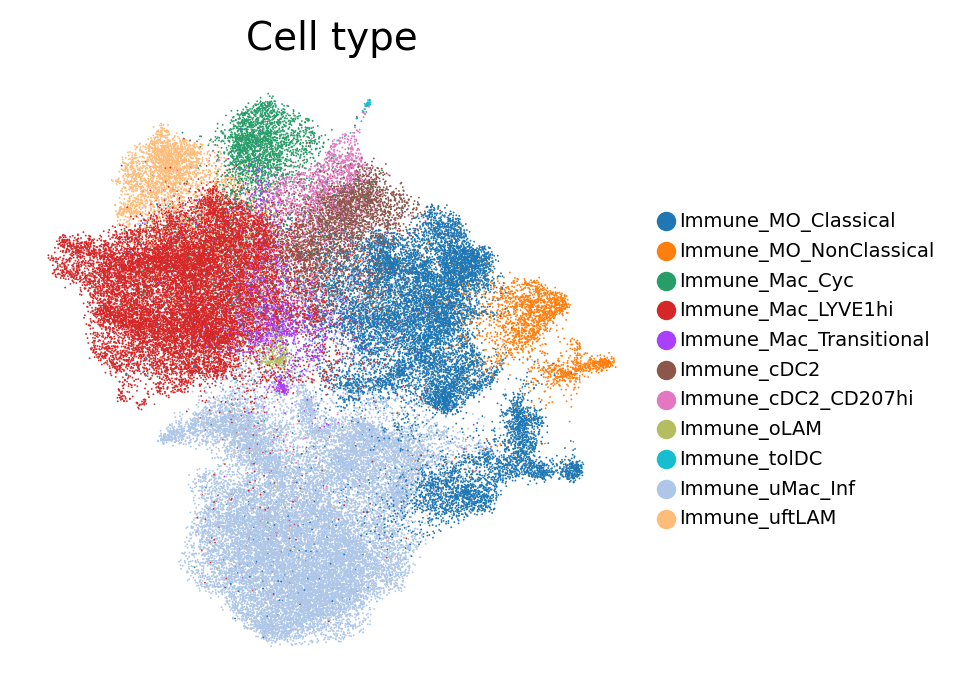

In [7]:
# 3. Cast to category for plotting
sc.pl.umap(
    adata,
    color           = "celltype_HCA",
    # legend_loc      = "on data",
    legend_fontsize = 7,
    title           = "Cell type"
)

## Map annotation levels and colors

Map HCA-approved cell ontology, containing levels (L) 1 through 4.

In [8]:
# Load immune cell taxonomy csv, with colors
ontology_info = pd.read_csv(ONTOLOGY_CSV)

ONTOLOGY_COLS = [
    "celltype_HCA",
    "L1",
    "L2",
    "L3",
    "L4"
]

cell_ontology = ontology_info[ONTOLOGY_COLS]

colors = pd.read_csv(L4_COLORS_CSV)
colors.drop(columns=["celltype_HCA_clean"], inplace=True)

In [9]:
# Merge ontology metadata
ont_color_df = cell_ontology.merge( 
    colors, 
    how='left',
    on="celltype_HCA"
)

new_obs = adata.obs.merge(
    ont_color_df, 
    how='left',
    on="celltype_HCA"
)

new_obs.index = adata.obs.index

adata.obs = new_obs

In [10]:
# Reorder the annotations for plotting
celltype_order = [
    "Immune_MO_Classical",
    "Immune_MO_NonClassical",
    "Immune_Mac_Transitional",
    "Immune_Mac_LYVE1hi",
    "Immune_uftLAM",
    "Immune_oLAM",
    "Immune_uMac_Inf",
    "Immune_Mac_Cyc",
    "Immune_cDC2",
    "Immune_cDC2_CD207hi",
    "Immune_tolDC"
]

col = "celltype_HCA"
adata.obs[col] = adata.obs[col].astype("category")
adata.obs[col] = adata.obs[col].cat.reorder_categories(
    celltype_order,
    ordered=True
)

adata.obs["celltype_HCA_code"] = (
    adata.obs["celltype_HCA_code"]
    .astype("category")
)

cats = adata.obs["celltype_HCA_code"].cat.categories

new_order = sorted(cats, key=lambda x: int(x))

adata.obs["celltype_HCA_code"] = (
    adata.obs["celltype_HCA_code"]
    .cat.reorder_categories(new_order, ordered=True)
)

In [11]:
# Clean cell type labels for plotting
adata.obs["celltype_HCA_clean"] = (
    adata.obs["celltype_HCA"]
    .cat.rename_categories(lambda x: x.replace("Immune_", ""))
)

In [12]:
# Generate adata.obs columns for plotting legend
adata.obs["celltype_legend"] = adata.obs["celltype_HCA_code"].astype(str) + " | " + adata.obs["celltype_HCA_clean"].astype(str)

# Ensure column is a category
adata.obs["celltype_legend"] = (
    adata.obs["celltype_legend"]
    .astype("category")
)

cats = adata.obs["celltype_legend"].cat.categories

new_order = sorted(
    cats,
    key=lambda x: int(x.split(" | ")[0])
)

adata.obs["celltype_legend"] = (
    adata.obs["celltype_legend"]
    .cat.reorder_categories(new_order, ordered=True)
)

In [13]:
# Map annotation colors
COLS_TO_COLOR = [
    "celltype_legend",
    "celltype_HCA",
    "celltype_HCA_clean",
    "celltype_HCA_code"
]

for COL in COLS_TO_COLOR:
    celltype_colors = (
        adata.obs[
            [COL, "celltype_HCA_color"]
        ]
        .drop_duplicates()
        .set_index(COL)["celltype_HCA_color"]
    )

    adata.uns[f"{COL}_colors"] = [
        celltype_colors[cat]
        for cat in adata.obs[COL].cat.categories
    ]

# 3. UMAP figures

## Extended Data Figure 5d

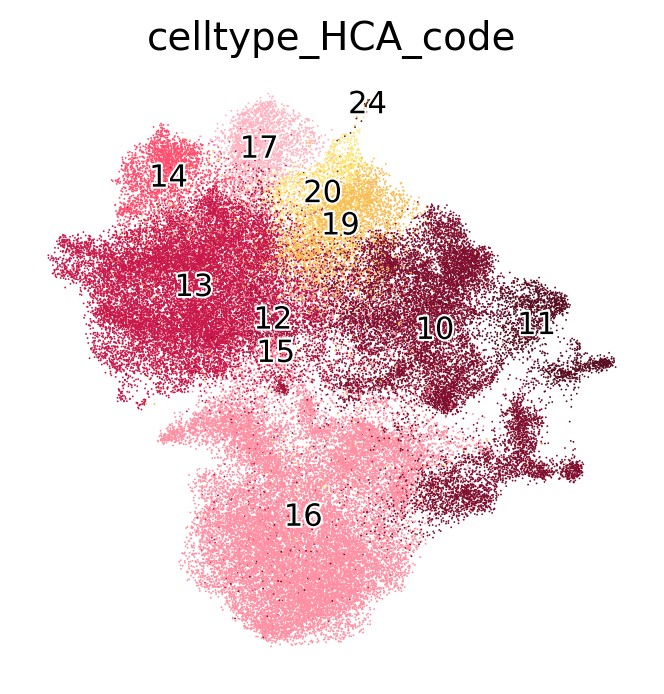

In [15]:
# Plot with annotation codes
sc.pl.umap(
    adata,
    color              = "celltype_HCA_code",
    ncols              = 1,
    legend_loc         = "on data",
    legend_fontsize    = 11,
    legend_fontweight  = "normal",
    legend_fontoutline = 1.5,
    # save               = f"_00_PLOT_acrosslifespan_noHormones_monomacscDC2.pdf",
)

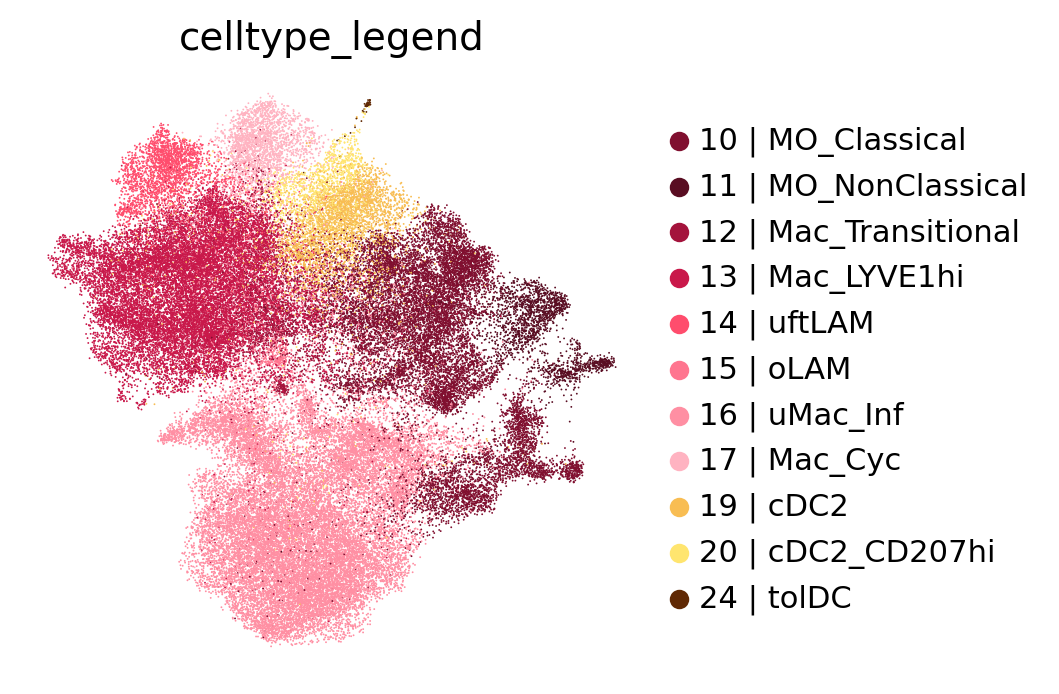

In [16]:
# Plot with annotation legend
sc.pl.umap(
    adata,
    color             = "celltype_legend",
    ncols             = 1,
    legend_loc        = "right margin",
    legend_fontsize   = 11,
    legend_fontweight = "normal",
    # save              = f"_00_LEGEND_acrosslifespan_noHormones_monomacscDC2.pdf",
)

—— FIN ——